Imports

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from adjustText import adjust_text
from matplotlib.lines import Line2D
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [4]:
import sys
print(sys.executable)

c:\Users\Ana\miniconda3\python.exe


General Data - Expression

In [5]:
gene_expression = pd.read_csv("C:\\Users\\Ana\\Documents\\Estágio\\Sun2023\\Expression_Genes_DESeq.csv")
gene_expression = gene_expression.rename(columns = {'Unnamed: 0': 'Gene'})
gene_expression.head()  # It shows the first 5 rows of a data frame

,Gene,WT_rep1,MECP2_rep1,WT_rep2,MECP2_rep2,WT_rep3,MECP2_rep3
0,DDX11L2,0,19,10,7,10,0
1,WASH7P,111,118,263,201,147,183
2,OR4F5,6,4,0,2,0,0
3,ENSG00000238009,41,55,41,33,28,7
4,CICP27,3,0,6,6,2,6


General Data - DEA

In [6]:
dea_res_genes = pd.read_csv("C:\\Users\\Ana\\Documents\\Estágio\\Sun2023\\DEA_Genes_DESeq.csv")
dea_res_genes = dea_res_genes.rename(columns={'Unnamed: 0': 'Gene'})
dea_res_genes = dea_res_genes.dropna(subset=['padj'])
dea_res_genes.head()

,Gene,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
0,MMP14,786.816378,7.085980,0.561611,12.617228,1.696894e-36,3.252097e-32
1,COL3A1,47530.232053,8.857806,0.708451,12.503055,7.183645e-36,6.883728e-32
2,UBB,1174.793140,10.911592,0.932863,11.696889,1.322122e-31,8.446154e-28
3,HOXD10,1346.473812,7.757375,0.718024,10.803779,3.303239e-27,1.582664e-23
4,IGF2,3101.936569,6.552475,0.613016,10.688913,1.147069e-26,4.396716e-23


Volcano Plot

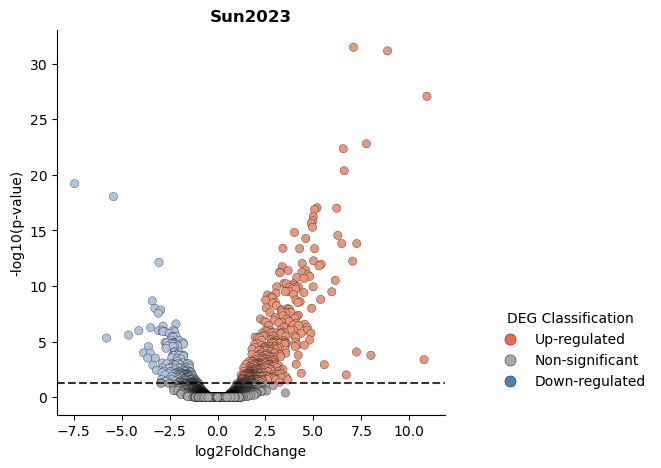

In [11]:
# Makes a new -log10(p-value) column and discards the genes with a p-value bigger than 0.05
def arrange_significant_values():
    global dea_res_genes
    dea_res_genes['-log10(p-value)'] = -np.log10(dea_res_genes['padj']) #Adds the -log10 column

    dea_res_genes['Classification'] = dea_res_genes.apply(
        lambda row: # Cria ua função anónima, rápida e sem nome, é bom utilizar quando não a vamos reutilizar
        'Up-regulated' if (row['log2FoldChange'] > 0.5 and row['padj'] < 0.05) 
        else (
            'Down-regulated' if(row['log2FoldChange'] < -0.5 and row['padj'] < 0.05)
            else 'Non-significant'),
        axis = 1) # Como o axis do apply é 1, a operação percorre a linha, andando de coluna em coluna

# Designates the genes_of_interest: the 5 genes with the biggest change in expression and 5 genes with the lowest change in expression
def get_genes_of_interest():
    global dea_res_genes
    top_up_genes = dea_res_genes.nlargest(5, 'log2FoldChange')['Gene'].tolist() #É preciso fazer tolist pq se não seria uma lista e não conseguiria somar
    top_down_genes = dea_res_genes.nsmallest(5, 'log2FoldChange')['Gene'].tolist()
    genes_of_interest = top_up_genes + top_down_genes

    dea_res_genes['Classification'] = np.where(dea_res_genes['Gene'].isin(genes_of_interest),  #Main
                                            'GOI_' + dea_res_genes['Classification'], 
                                            dea_res_genes['Classification']) # Se o gene for um gene de interesse, adiciona GOI_ à classificaçao, se não mantêm como estava

    return genes_of_interest

# Sets the reference lines and the plot's labels
def set_lines_and_labels(ax):
    ax.axhline(y = -np.log10(0.05), color = 'black' , linestyle = '--', alpha = 0.8) #Cria uma linha horizontal de referência, alpha é a transparência da linha

    ax.set_title('Sun2023', fontweight = 'bold', fontsize = 12)
    ax.set_xlabel('log2FoldChange')
    ax.set_ylabel('-log10(p-value)')

# Sets the genes of interest's legend
def set_genes_of_interest_legend(ax):
    genes_of_interest = get_genes_of_interest()
    print(genes_of_interest)
    texts = []

    for i, row in dea_res_genes.iterrows(): # index é o nome ou número da linhas, row é a linha inteira.
        if row['Gene'] in genes_of_interest:
            if pd.isna(row['log2FoldChange']) or pd.isna(row['-log10(p-value)']):
                print(f"Atenção: {row['Gene']} tem NaN em log2FoldChange ou -log10(p-value)")
                continue
            texts.append(ax.text(row['log2FoldChange'], row['-log10(p-value)'], row['Gene'], 
                                fontsize = 8, color = 'black', fontweight = 'semibold')) #ax.text escreve texto em qualquer coordenada do gráfico

    adjust_text(texts, ax = ax, expand_points = (10, 10), force_points = 0.2,
                arrowprops = dict(arrowstyle = '-', color = 'black', lw = 0.8), save_steps = False) # O expand_points define a distância mínima que o texto deve manter em relação aos pontos dos dados, aceita um tuple com 2 números, um para o eixo x e outro para o y
    print(texts)

# Sets the plot's legend
def set_plot_legend(ax):
    legend_elements = [Line2D([0], [0], marker = 'o', color = 'w', markerfacecolor = 'tomato', # Como estamos a criar uma legenda (o line2D é quase sempre para isto), as coordenadas são 0
                            markeredgecolor = 'k', markersize = 8, markeredgewidth = 0.3, 
                            label = 'Up-regulated'),
                    Line2D([0], [0], marker = 'o', color = 'w', markerfacecolor = 'darkgray',
                            markeredgecolor = 'k', markersize = 8, markeredgewidth = 0.3,
                            label = 'Non-significant'),
                    Line2D([0], [0], marker = 'o', color = 'w', markerfacecolor = 'steelblue',
                            markeredgecolor = 'k', markersize = 8, markeredgewidth = 0.3,
                            label = 'Down-regulated')]

    ax.legend(handles = legend_elements, title = 'DEG Classification', bbox_to_anchor = (1.1, 0.3), frameon = False)
    #set_genes_of_interest_legend(ax)


def get_volcano_plot():
    arrange_significant_values()
    fig, ax = plt.subplots(figsize = (5, 5))

    pallete_dea = { 'GOI_Up-regulated' : 'tomato',
            'GOI_Down-regulated' : 'steelblue',
            'Up-regulated' : 'darksalmon',
            'Non-significant' : 'darkgray',
            'Down-regulated' : 'lightsteelblue'} # Defines the dots colors

    sns.scatterplot(data = dea_res_genes,
                    x = 'log2FoldChange',
                    y = '-log10(p-value)',
                    palette = pallete_dea,
                    hue = 'Classification',
                    edgecolor = 'black',
                    linewidth = 0.2,
                    legend = False)
    
    set_lines_and_labels(ax)
    set_plot_legend(ax)
    sns.despine()
    plt.show()


get_volcano_plot()


PCA - Data Frame

In [8]:
genes = gene_expression.iloc[:,0]
counts = gene_expression.iloc[:, 1:]

library_size = counts.sum(axis = 0) # Soma todas as counts numa coluna!
cpm = counts.div(library_size, axis = 1) * 1e6
log2cpm = np.log2(cpm + 1)

clinical_data = pd.read_csv("C:\\Users\\Ana\\Documents\\Estágio\\Sun2023\\SraRunTable_Sun23.csv")
clinical_data = clinical_data[['Sample_Name', 'Condition', 'Run']]
scaler = StandardScaler()
scaled_data = scaler.fit_transform(log2cpm.T) # .T é essencial pq as linhas no PCA são as amostras e as colunas são os genes!
pca = PCA(n_components = 2)
pca_res = pca.fit_transform(scaled_data) # fit calcula as componentes principais e o transform projeta os dados nessas componentes
                                         # As linhas são amostras as colunas são PCs
pca_df = pd.DataFrame(pca_res, index = log2cpm.columns, columns = [f"PC{i+1}" for i in range(2)]) #O index mantêm o nome das amostras
pca_df.reset_index(names = 'Sample_Name', inplace = True) #Nesessário fazer para que o merge resulte! Pq o merge só junta colunas
pca_df = pca_df.merge(clinical_data, on = 'Sample_Name', how = 'left') # Junta as 2 tabelas para que vejamos o run e a condição na tabela
pca_df

,Sample_Name,PC1,PC2,Condition,Run
0,WT_rep1,168.316531,-109.199725,WT,SRR16497780
1,MECP2_rep1,137.945813,143.663780,MECP2_R270X,SRR16497781
2,WT_rep2,-82.592768,-49.017650,WT,SRR16497782
3,MECP2_rep2,-24.640657,31.704976,MECP2_R270X,SRR16497783
4,WT_rep3,-46.330610,-68.855087,WT,SRR16497784
5,MECP2_rep3,-152.698309,51.703705,MECP2_R270X,SRR16497785


PCA - Graph

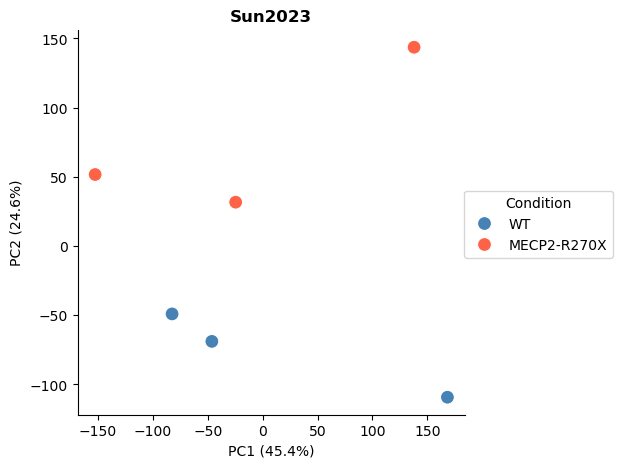

In [13]:
fig, ax = plt.subplots(figsize = (5, 5))
palette_pca = {'WT' : 'steelblue',
               'MECP2-R270X' : 'tomato'}

pca_df["Condition"] = pca_df["Condition"].replace({"MECP2_R270X": "MECP2-R270X"})
sns.scatterplot(data = pca_df, x = 'PC1', y = 'PC2', palette = palette_pca, hue = 'Condition', s = 100)
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)") # f-string é uma forma moderna de formatar strings em python, valor da variância * 100 para meter em percentagem e dps coloca só com uma casa decimal
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
ax.set_title("Sun2023", fontweight = 'bold', fontsize = 12)
ax.legend(title = 'Condition', bbox_to_anchor = (1.4, 0.6))
sns.despine()
plt.show()


Boxplot

       Sample    Condition          Run
0     WT_rep1           WT  SRR16497780
1  MECP2_rep1  MECP2_R270X  SRR16497781
2     WT_rep2           WT  SRR16497782
3  MECP2_rep2  MECP2_R270X  SRR16497783
4     WT_rep3           WT  SRR16497784
     Gene   Sample  log2(CPM) Condition          Run
0  HOXD10  WT_rep1   1.135621        WT  SRR16497780
1  COL3A1  WT_rep1   4.296845        WT  SRR16497780
2   H3C11  WT_rep1   3.772902        WT  SRR16497780
3   H4C13  WT_rep1   0.998274        WT  SRR16497780
4  CHCHD2  WT_rep1   6.630303        WT  SRR16497780


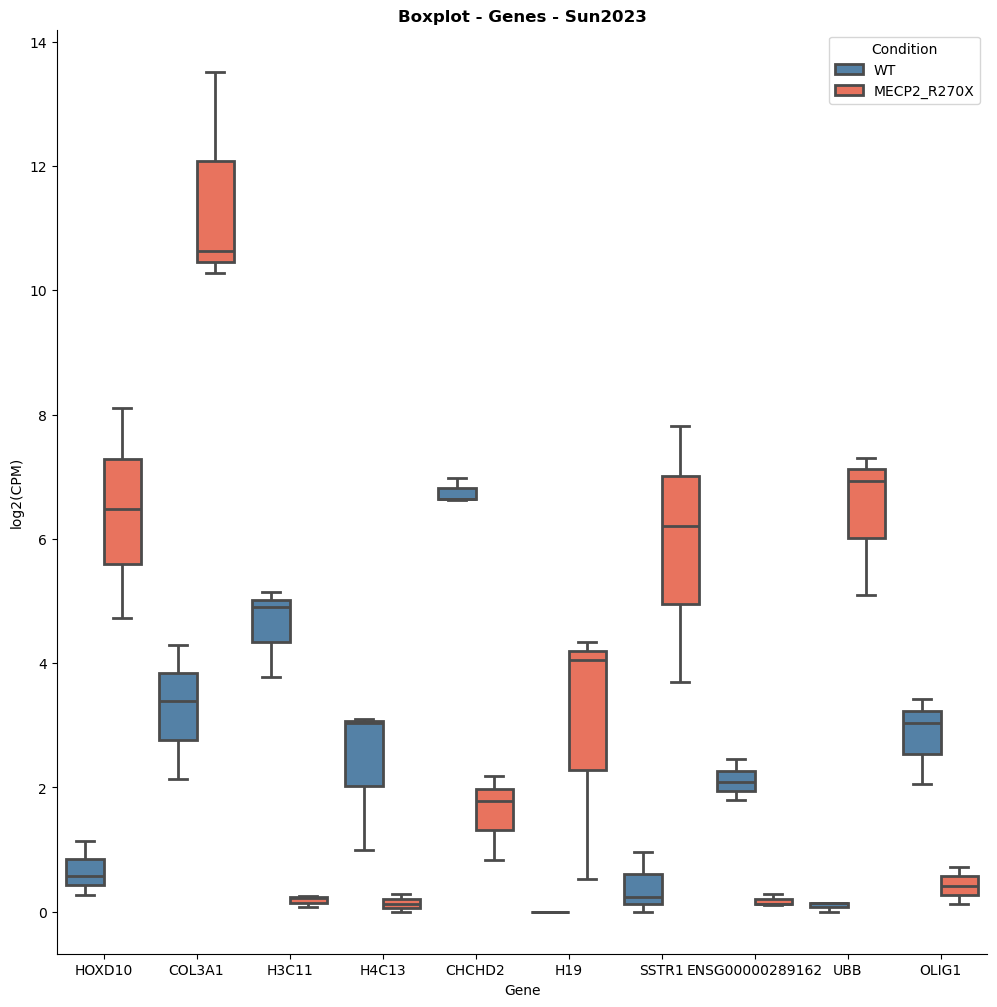

In [10]:
fig, ax = plt.subplots(figsize = (12,12))
genes = gene_expression.iloc[:,0]
counts = gene_expression.iloc[:, 1:]

library_size = counts.sum(axis = 0) # Soma todas as counts numa coluna!
cpm = counts.div(library_size, axis = 1) * 1e6
log2cpm_df = np.log2(cpm + 1) #Ainda é uma data frame aqui
log2cpm_df.insert(0, 'Gene', genes)

genes_of_interest = get_genes_of_interest()
goi_df = log2cpm_df[log2cpm_df['Gene'].isin(genes_of_interest)]
long_df = goi_df.melt(id_vars = 'Gene', var_name = 'Sample', value_name = 'log2(CPM)')
# O melt basicamente transforma a data frame numa data frame com 3 colunas, uma de genes, uma de samples e outra de log2CPM, essencial para fazer o boxplot
# O var_name é a coluna que vai ficar com todos os nomes das amostras, a coluna value vai ficar com todos os valores que estavam na dataframe original
clinical_data.rename(columns = {'Sample_Name' : 'Sample'}, inplace = True)
print(clinical_data.head())
long_df = long_df.merge(clinical_data, on = 'Sample', how = 'left')
print(long_df.head())

palette_boxplot = {'MECP2_R270X' : 'tomato',
                   'WT' : 'steelblue'}

sns.boxplot(data = long_df, x = 'Gene', y = 'log2(CPM)', hue = 'Condition', palette = palette_boxplot,
            color = 'tomato', fliersize = 2, linewidth = 2)

ax.set_title('Boxplot - Genes - Sun2023', fontweight = 'bold', fontsize = 12)
ax.set_xlabel('Gene')
ax.set_ylabel('log2(CPM)')

sns.despine()
plt.show()

